In [44]:
import pandas as pd

In [45]:
df = pd.read_csv("abt_churn.csv")

In [46]:
df.head()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


## 1. S - Sample (Amostragem)
O primeiro passo é garantir que o modelo seja treinado e validado em amostras
justas e representativas, evitando o vazamento de dados (data leakage) e
garantindo a estabilidade temporal.
- Out-of-Time (OOT): Separe a safra de dados mais recente (o último mês
disponível na base) e reserve-a. Essa base não deve ser tocada até o final
do projeto; ela servirá para testar a estabilidade do modelo no tempo.
- Train/Test Split: Com o restante dos dados, faça a divisão clássica entre
base de Treino (ex: 80%) e base de Teste (ex: 20%).
- Estratificação: Ao fazer o split, garanta que a proporção da variável
resposta (flag de Churn) seja idêntica tanto no Treino quanto no Teste.

In [47]:
# Analisando ocorrências das datas
df["dtRef"].value_counts().sort_index(ascending=False)

dtRef
2025-04-01    303
2025-03-01    451
2025-02-01    374
2025-01-01    194
2024-12-01    198
2024-11-01    258
2024-10-01    349
2024-09-01    371
2024-08-01    415
2024-07-01    422
2024-06-01    426
2024-05-01    542
2024-04-01    528
2024-03-01    665
Name: count, dtype: int64

Não há nenhum registro que ocorreu fora do primeiro dia de cada mês, sendo possível apenas isolar os registros da data "2025-04-01"

In [48]:
# Isolando o último mês mais recente disponível na base
df_oot = df[df["dtRef"] == "2025-04-01"].copy().drop(columns=["dtRef", "idUsuario"])
df_model = df[df["dtRef"] != "2025-04-01"].copy().drop(columns=["dtRef", "idUsuario"])

# Divisão de variáveis (Features vs Target)
X = df_model.drop(columns=["flagChurn"])
y = df_model["flagChurn"]

from sklearn.model_selection import train_test_split

# Split com Estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2. E - Explore (Exploração)
Antes de modificar os dados, é necessário conhecê-los intimamente. O
objetivo é identificar quais variáveis têm maior potencial para explicar o
Churn. Sendo toda a exploração feita apenas na base de treino.

- Verificação de Qualidade: Identifique se existem valores nulos (missings)
na base. Se existirem, proponha uma estratégia de tratamento sem vazar
dados da variável resposta.
- Análise Bivariada: Compare o comportamento das variáveis explicativas
(médias, medianas) separando os grupos entre quem "Deu Churn" (1) e
quem "Não Deu Churn" (0).
- Feature Importance Inicial: Ajuste uma Árvore de Decisão simples
utilizando todas as variáveis contra a variável target. Extraia a importância
das variáveis (feature importance) para ranquear quais colunas parecem
ser mais promissoras.

### Verificação de qualidade

In [49]:
# Verificando Features, colunas com valores nulos e sua quantidade
colunas_nan_X = X_train.isnull().sum()
colunas_nan_X = colunas_nan_X[colunas_nan_X > 0]
print(colunas_nan_X)

Series([], dtype: int64)


In [50]:
# Verificando Target, quantidade de nulos
colunas_nan_y = y_train.isnull().sum()
colunas_nan_y = colunas_nan_y[colunas_nan_y > 0]
print(colunas_nan_y)

[]


Não há nenhum valor nulo na base de treino, não sendo necessário tratamento

### Análise Bivariada

In [51]:
# Análise Bivariada: distanciamento estátistico - Média e Mediana

df_analise = X_train.copy()
df_analise["target"] = y_train

media = df_analise.groupby("target").mean(numeric_only=True).T
mediana = df_analise.groupby("target").median(numeric_only=True).T

media.columns = ["Não deu Churn", "Deu Churn"]
mediana.columns = ["Não deu Churn", "Deu Churn"]

comparacao = pd.concat(
    [media, mediana],
    axis=1,
    keys=["Média", "Mediana"]
)

comparacao

Média                   Mediana            
                           Não deu Churn   Deu Churn Não deu Churn   Deu Churn
qtdeTransacoes                326.906618   50.051335     52.000000    8.000000
qtdeDias                       29.777879    9.129877     13.000000    3.000000
mediaTransacoesDias             6.380571    3.927910      3.557778    2.083916
saldoPontos                  1451.726201  439.316735    563.000000  123.000000
qtdePontosPos                3073.557117  648.484600    705.000000  126.500000
qtdePontosNeg               -1621.830916 -209.167864      0.000000    0.000000
qtdeDiasUltimaTransacao         6.687670   13.425051      4.000000   14.000000
qtdeDiasPrimeiraTransacao      98.655938   72.504620     63.000000   30.000000
qtdSkuDistintos                 3.610154    2.178645      3.000000    2.000000
qtdeChatMessage               288.233001   40.677105     34.000000    5.000000
qtdePresença                   26.231188    7.726386     10.000000    2.000000
qtdeTrocaStreamElements         1.480054    0.180185      0.000000    0.000000
qtdeChurn                       5.716682    0.622177      0.000000    0.000000
qtdePonei                       1.914325    0.323922      0.000000    0.000000
qtdeAirflowLover                0.126020    0.014887      0.000000    0.000000
qtdePresencaStreak              2.061197    0.310575      0.000000    0.000000
qtdeDailyLoot                   0.782412    0.124230      0.000000    0.000000
qtdeRLover                      0.067090    0.006160      0.000000    0.000000
qtdeVendaItemRPG                0.290571    0.065195      0.000000    0.000000
qtdeTransacoesD7               14.084769    1.754620      3.000000    0.000000
qtdeDiasD7                      1.834995    0.391684      1.000000    0.000000
saldoPontosD7                  91.972801   14.834189     50.000000    0.000000
qtdePontosPosD7               159.402539   18.478953     52.000000    0.000000
qtdePontosNegD7               -67.429737   -3.644764      0.000000    0.000000
qtdeTransacoesD14              27.636446    3.598563      6.000000    1.000000
qtdeDiasD14                     3.505440    0.833676      3.000000    1.000000
saldoPontosD14                179.610154   31.100616    100.000000    1.000000
qtdePontosPosD14              316.513599   38.107803    107.000000    1.000000
qtdePontosNegD14             -136.903445   -7.007187      0.000000    0.000000
qtdeTransacoesD28              55.080236    9.584702     14.000000    3.000000
qtdeDiasD28                     6.825023    2.161191      5.000000    1.000000
saldoPontosD28                317.289211   92.721253    158.000000   51.000000
qtdePontosPosD28              617.361287  114.487166    213.500000   52.000000
qtdePontosNegD28             -300.072076  -21.765914      0.000000    0.000000
propAvgQtdeTransacoes           4.450259    0.686240      0.821447    0.132684
propAvgQtdeDias                 3.102036    0.970140      1.627622    0.428842
propAvgMediaTransacoesDias      1.470546    0.906993      0.833010    0.501362
propAvgSaldoPontos              3.088453    0.936159      1.287811    0.315995
propAvgQtdePontosPos            3.851269    0.826442      1.079876    0.207665
propAvgQtdePontosNeg            4.993870    0.612794      0.000000    0.000000

É possível perceber através da diferença entre a média e mediana uma grande dispersão de dados em várias features do dataset, tanto para "Deu Churn" quanto para "Não deu Churn", também é possível inferir que em geral quem "Deu Churn" apresenta valores menores que quem "Não deu Churn".

### Feature Importance Inicial

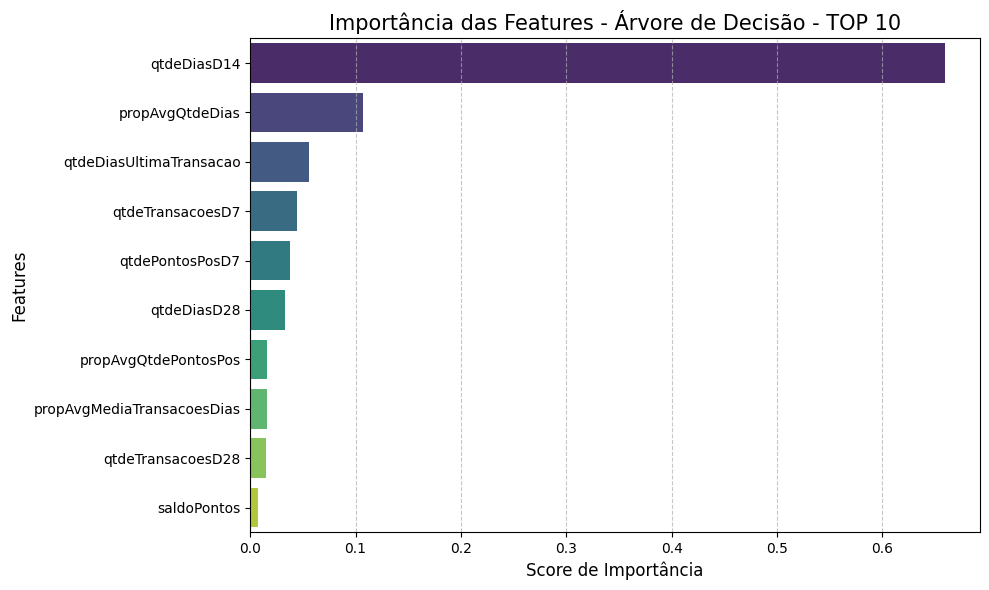

In [52]:
from sklearn.tree import DecisionTreeClassifier

# Selecionando apenas colunas númericas
X_train_numerico = X_train.select_dtypes(include="number")

# Árvore de Decisão rápida para caçar padrões iniciais
arvore_rapida = DecisionTreeClassifier(max_depth=4)
arvore_rapida.fit(X_train_numerico, y_train)



# Extraindo Feature Importance
importancia_features = pd.Series(
    arvore_rapida.feature_importances_, index=X_train_numerico.columns
)

top_10_features = importancia_features.sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values,
            y=top_10_features.index,
            hue=top_10_features.index,
            palette="viridis",
            legend=False)

# 3. Estilização
plt.title("Importância das Features - Árvore de Decisão - TOP 10", fontsize=15)
plt.xlabel("Score de Importância", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Claramente há uma grande diferença percebida pela Árvore de Decisão, em relação a importância de cada feature, sendo a "qtdeDias14" considerada de longe, a mais importante. Há outras features que demonstram certa importância como "propAvgQtdeDias" e "qtdeDiasUltimaTransacao".

## 3. M - Modify (Modificação)
Etapa voltada para transformar os dados brutos para facilitar o aprendizado dos algoritmos.
- Discretização (Binning): Escolha variáveis contínuas importantes (ex: dias desde a última transação) e transforme-as em faixas/categorias. Você pode usar árvores de decisão para encontrar os melhores cortes.
- Codificação de Variáveis (Encoding): Como os algoritmos matemáticos
não lidam bem com textos ou classes ordinais não balanceadas, aplique
técnicas como One-Hot Encoding nas variáveis discretizadas ou categóricas.
- Boas Práticas (Opcional, mas recomendado): Tente encapsular essas
etapas de transformação utilizando a classe Pipeline do Scikit-Learn. Isso evitará que você tenha que repetir o código de transformação para as bases de teste e OOT.

In [53]:
X_train[top_10_features.index.tolist()]

,qtdeDiasD14,propAvgQtdeDias,qtdeDiasUltimaTransacao,qtdeTransacoesD7,qtdePontosPosD7,qtdeDiasD28,propAvgQtdePontosPos,propAvgMediaTransacoesDias,qtdeTransacoesD28,saldoPontos
1283,3,0.289318,10.0,0,0,3,0.174560,0.241858,3,150
3015,2,0.482197,6.0,2,51,5,0.299079,0.580460,12,257
3773,1,2.994404,6.0,1,50,5,2.763287,0.386389,13,1969
1823,1,0.165473,7.0,4,53,1,0.109515,0.875096,4,53
4577,0,0.607107,15.0,0,0,1,0.242994,1.145970,1,228
...,...,...,...,...,...,...,...,...,...,...
162,3,1.763257,5.0,4,53,4,1.077548,0.621917,11,626
770,2,0.539178,11.0,0,0,2,0.340563,0.215391,2,100
1089,1,0.269589,3.0,2,51,1,0.173687,0.430781,2,51
4114,10,2.893180,2.0,13,357,19,1.888739,0.427283,38,1623


As variáveis contínuas mais importantes são "propAvgQtdeDias", "propAvgQtdePontosPos" e "propAvgMediaTransacoesDias"

### Pipeline modificador - Discretização (Binning)/ Codificação de Variáveis (Encoding)

In [54]:
from feature_engine.discretisation import DecisionTreeDiscretiser
from feature_engine.encoding import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

variaveis_continuas = ["propAvgQtdeDias", "propAvgQtdePontosPos", "propAvgMediaTransacoesDias"]

discretizador = DecisionTreeDiscretiser(
                  cv=3, 
                  scoring='roc_auc', 
                  variables= variaveis_continuas,
                  regression=False,
                  bin_output='boundaries',
                  precision=2
              )

codificador = OneHotEncoder(variables= variaveis_continuas)

modificador = Pipeline(steps=[
    ('discretizer', discretizador),
    ('encoder', codificador),
    ])

### Visualizando dados transformados

In [55]:
modificador.fit(X_train, y_train)
X_train_transformed = modificador.transform(X_train)

display(X_train.head())
display(X_train_transformed.head())

,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,qtdSkuDistintos,qtdeChatMessage,...,qtdeDiasD28,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg
1283,3,3,1.000000,150,150,0,10.0,12.0,1,0,...,3,150,150,0,0.038607,0.289318,0.241858,0.295608,0.174560,0.0
3015,12,5,2.400000,257,257,0,6.0,25.0,2,7,...,5,257,257,0,0.154430,0.482197,0.580460,0.506474,0.299079,0.0
3773,47,27,1.740741,1969,1969,0,6.0,98.0,4,19,...,5,757,757,0,0.640393,2.994404,0.386389,4.361164,2.763287,0.0
1823,4,1,4.000000,53,53,0,7.0,7.0,2,3,...,1,53,53,0,0.080967,0.165473,0.875096,0.153916,0.109515,0.0
4577,32,7,4.571429,228,228,0,15.0,107.0,2,28,...,1,1,1,0,0.395953,0.607107,1.145970,0.439370,0.242994,0.0


,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,qtdSkuDistintos,qtdeChatMessage,...,"propAvgQtdePontosPos_(0.0021, 0.11]","propAvgQtdePontosPos_(-inf, 0.0021]","propAvgMediaTransacoesDias_(0.214, 0.251]","propAvgMediaTransacoesDias_(0.444, 0.867]","propAvgMediaTransacoesDias_(0.256, 0.444]","propAvgMediaTransacoesDias_(0.867, 5.111]","propAvgMediaTransacoesDias_(5.111, inf]","propAvgMediaTransacoesDias_(0.251, 0.252]","propAvgMediaTransacoesDias_(-inf, 0.214]","propAvgMediaTransacoesDias_(0.252, 0.256]"
1283,3,3,1.000000,150,150,0,10.0,12.0,1,0,...,0,0,1,0,0,0,0,0,0,0
3015,12,5,2.400000,257,257,0,6.0,25.0,2,7,...,0,0,0,1,0,0,0,0,0,0
3773,47,27,1.740741,1969,1969,0,6.0,98.0,4,19,...,0,0,0,0,1,0,0,0,0,0
1823,4,1,4.000000,53,53,0,7.0,7.0,2,3,...,0,0,0,0,0,1,0,0,0,0
4577,32,7,4.571429,228,228,0,15.0,107.0,2,28,...,0,0,0,0,0,1,0,0,0,0
